# Perceptron Simples

## Importações

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import random

## Leitura dos dados

In [2]:
treinamento = pd.read_csv('dataset/diabetes_train.csv')

In [3]:
teste = pd.read_csv('dataset/diabetes_test.csv')

## Pré-processamento

In [4]:
class Encoders:
    def __init__(self):
        self.encoders = {}

    def add_encoder(self, feature, encoder):
        self.encoders[feature] = encoder

    def get_encoder(self, feature):
        try:
            return self.encoders[feature]
        except KeyError:
            return None

In [5]:
encoders = Encoders()

In [6]:
def cria_encoder(feature, nome, encoders):
    encoder = LabelEncoder()
    feature_codificada = encoder.fit_transform(feature)
    encoders.add_encoder(nome, encoder)
    return feature_codificada


In [7]:
def verifica_features_categoricas(dados, encoders):
    for i in range(int(dados.size/len(dados)) - 1):
        feature = dados.iloc[:, i]
        if not all(isinstance(instancia, (int, float)) for instancia in (feature.values).tolist()):
            y = encoders.get_encoder(feature.name)
            if y == None:
                dados.loc[:, feature.name] = cria_encoder((feature.values).tolist(), feature.name, encoders)
            else:
                dados.loc[:, feature.name] = y.transform((feature.values).tolist())
    
    return dados

In [8]:
treinamento = verifica_features_categoricas(treinamento, encoders)
teste = verifica_features_categoricas(teste, encoders)

In [11]:
x_treinamento, x_teste = treinamento.iloc[:, :-1].values, teste.iloc[:, :-1].values

In [12]:
normalizador = MinMaxScaler()
normalizador.fit(x_treinamento)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [13]:
x_treinamento, x_teste = normalizador.transform(x_treinamento), normalizador.transform(x_teste)

In [14]:
y_treinamento, y_teste = treinamento.iloc[:, -1].values, teste.iloc[:, -1].values

## Algoritmo

In [ ]:
class SimplePerceptron:
    def __init__(self, alpha = 1, max_epocas = 10000):
        self.pesos = None
        self.entradas = None
        self.saidas = None
        self.taxa_aprendizado = alpha
        self.max_epocas = max_epocas
        self.qtd_epocas = 0
        self.historico_erros = []

    def __aleatoriza_pesos(self, r, qtd_pesos):
        self.pesos = np.empty(qtd_pesos + 1)
        
        for i in range(qtd_pesos + 1):
            self.pesos[i] = (random.triangular(-r, r))

    def __aleatoriza_dataset(self):
        indices = np.arange(len(self.entradas))
        np.random.shuffle(indices)
        
        self.entradas = self.entradas[indices]
        self.saidas = self.saidas[indices]

    def __calcula_saida_atual(self, x):
        u = np.dot(x, self.pesos)

        if u >= 0: 
            return 1
        
        return 0

    def __perceptron(self):
        erro_total = 1000
        self.__aleatoriza_pesos(1, int(self.entradas.size/len(self.entradas)))

        while(erro_total > (len(self.entradas) * 0.07) and self.max_epocas >= self.qtd_epocas):
            self.__aleatoriza_dataset()
            matriz_design = np.column_stack([np.ones(len(self.entradas)) * -1, self.entradas])
            self.qtd_epocas += 1
            erro_total = 0

            for i, x in enumerate(matriz_design):
                y = self.__calcula_saida_atual(x)
                erro = self.saidas[i] - y
                pesos_atuais = self.pesos + self.taxa_aprendizado * erro * x
                erro_total += int(erro != 0)
                self.pesos = pesos_atuais
            
            self.historico_erros.append(erro_total)

    def curva_convergencia(self):
        iteracoes = np.arange(self.qtd_epocas)
        plt.plot(iteracoes, self.historico_erros)
        plt.xlabel("Iterações")
        plt.ylabel("Erro")
        plt.title("Curva de Convergência")
        plt.show()
    
    def fit(self, x, y):
        self.entradas = x
        self.saidas = y
        self.__perceptron()

    def predict(self, x):
        matriz_design = np.column_stack([np.ones(len(x)) * -1, x])
        return list(map(self.__calcula_saida_atual, matriz_design))

In [126]:
perceptron = SimplePerceptron()
perceptron.fit(x_treinamento, y_treinamento)

In [127]:
resultados = perceptron.predict(x_teste)

In [20]:
def confusion_matrix(previsoes, real):
    matriz_confusao = np.zeros((2, 2))

    for i, k in zip(previsoes, real):
        matriz_confusao[k][i] += 1

    return matriz_confusao

In [21]:
def score(y_resultado, y_teste):
    matriz_confusao = confusion_matrix(y_resultado, y_teste)

    acuracia = np.sum(np.diagonal(matriz_confusao))/np.sum(matriz_confusao)
    precisao = (matriz_confusao[1][1]/(np.sum(matriz_confusao[:, 1])))
    revocacao = (matriz_confusao[1][1] / (np.sum(matriz_confusao[1][:])))
    f1_score = (2/((1/precisao) + 1/(revocacao)))

    print("=" * 10 + " Medições de Desempenho " + "=" * 10)
    print("Matriz de Confusão")
    print(f"{pd.DataFrame(matriz_confusao, columns=['0', '1'])}")
    print(f"\nAcurácia: {acuracia:.4f}")
    print(f"Precisão: {precisao:.4f}")
    print(f"Revocação: {revocacao:.4f}")
    print(f"F1-Score: {f1_score:.4f}")
    print("=" * 44)

In [128]:
score(resultados, y_teste)

========== Medições de Desempenho ==========
Matriz de Confusão
      0      1
0  78.0    3.0
1  10.0  117.0

Acurácia: 0.9375
Precisão: 0.9750
Revocação: 0.9213
F1-Score: 0.9474


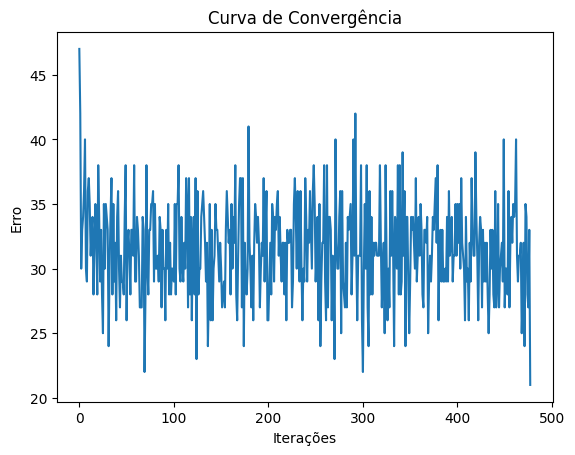

In [129]:
perceptron.curva_convergencia()